# 09 · Model Building

**Objective:** Build and compare models for all three ML use cases in this project — funding regression, exit classification, and startup clustering — matching `src/ml/funding_regression.py`, `src/ml/success_classification.py`, and `src/ml/clustering.py`.

This notebook runs a full **live** scikit-learn model comparison (which already covers most of the algorithms worth trying: Linear/Ridge/Lasso, Decision Tree, Random Forest, Extra Trees, Gradient Boosting, HistGradientBoosting, AdaBoost, Logistic Regression), then compares it against my **already-trained** XGBoost results (`data/warehouse/*_model_comparison.csv`, from `src/ml/funding_regression.py` and `src/ml/success_classification.py`) to see how the two approaches stack up against each other.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier, ExtraTreesRegressor,
                               GradientBoostingRegressor, HistGradientBoostingRegressor,
                               HistGradientBoostingClassifier, AdaBoostRegressor)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, accuracy_score,
                              precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix)

pd.set_option("display.max_columns", 30)
WH = Path("data/warehouse")

fact = pd.read_csv(WH / "fact_startup_funding.csv", low_memory=False)
startup = pd.read_csv(WH / "dim_startup_with_source_key.csv", low_memory=False)
geo = pd.read_csv(WH / "dim_geography.csv", low_memory=False)
industry = pd.read_csv(WH / "dim_industry.csv", low_memory=False)
df = fact.merge(startup, on="startup_id").merge(geo, on="geography_id", how="left").merge(industry, on="industry_id", how="left")

top_industries = df["primary_category"].value_counts().head(15).index
df["industry_grouped"] = np.where(df["primary_category"].isin(top_industries), df["primary_category"], "Other")
top_countries = df["country_name"].value_counts().head(15).index
df["country_grouped"] = np.where(df["country_name"].isin(top_countries), df["country_name"], "Other")
df["is_multi_round"] = df["is_multi_round"].astype(int)
df["has_debt_financing"] = df["has_debt_financing"].astype(int)

FEATURE_COLS_NUMERIC = ["funding_rounds", "years_since_founded", "is_multi_round",
                         "num_round_types_used", "has_debt_financing", "category_count"]
FEATURE_COLS_CATEGORICAL = ["industry_grouped", "country_grouped"]
preprocessor = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), FEATURE_COLS_CATEGORICAL)], remainder="passthrough")
print("Setup complete.")

Setup complete.


## Use Case 1 — Funding Amount Prediction (Regression)

Target: `log_funding_total_usd`. Same train/test split as notebook 07.

In [1]:
reg_df = df.dropna(subset=["log_funding_total_usd"] + FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL)
X = reg_df[FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL]
y = reg_df["log_funding_total_usd"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Modeling dataset: {len(reg_df):,} rows | Train: {len(X_train):,} | Test: {len(X_test):,}")

def evaluate_reg(name, pipeline):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    cv = cross_val_score(pipeline, X_train, y_train, cv=3, scoring="r2")
    return {"name": name, "mae": mae, "rmse": rmse, "r2": r2, "cv_r2_mean": cv.mean(), "cv_r2_std": cv.std(), "pipeline": pipeline}

reg_results = []
reg_results.append(evaluate_reg("Linear Regression", Pipeline([("prep", preprocessor), ("model", LinearRegression())])))
reg_results.append(evaluate_reg("Ridge (alpha=1.0)", Pipeline([("prep", preprocessor), ("model", Ridge(alpha=1.0))])))
reg_results.append(evaluate_reg("Lasso (alpha=0.01)", Pipeline([("prep", preprocessor), ("model", Lasso(alpha=0.01))])))
reg_results.append(evaluate_reg("Decision Tree (depth=8)", Pipeline([("prep", preprocessor), ("model", DecisionTreeRegressor(max_depth=8, random_state=42))])))
reg_results.append(evaluate_reg("Random Forest", Pipeline([("prep", preprocessor), ("model", RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1))])))
reg_results.append(evaluate_reg("Extra Trees", Pipeline([("prep", preprocessor), ("model", ExtraTreesRegressor(n_estimators=150, max_depth=14, random_state=42, n_jobs=-1))])))
reg_results.append(evaluate_reg("Gradient Boosting", Pipeline([("prep", preprocessor), ("model", GradientBoostingRegressor(n_estimators=150, max_depth=3, random_state=42))])))
reg_results.append(evaluate_reg("HistGradientBoosting", Pipeline([("prep", preprocessor), ("model", HistGradientBoostingRegressor(max_depth=6, random_state=42))])))

reg_summary = pd.DataFrame([{k: v for k, v in r.items() if k != "pipeline"} for r in reg_results]).sort_values("r2", ascending=False)
reg_summary

Modeling dataset: 39,140 rows | Train: 31,312 | Test: 7,828


,name,mae,rmse,r2,cv_r2_mean,cv_r2_std
7,HistGradientBoosting,1.234779,1.625033,0.517364,0.512572,0.004281
6,Gradient Boosting,1.243391,1.632370,0.512995,0.506892,0.005487
4,Random Forest,1.251130,1.644321,0.505838,0.498675,0.003190
5,Extra Trees,1.253293,1.645693,0.505013,0.491431,0.000725
3,Decision Tree (depth=8),1.282105,1.684802,0.481207,0.479422,0.005567
1,Ridge (alpha=1.0),1.412125,1.828268,0.389092,0.371593,0.011369
0,Linear Regression,1.412124,1.828273,0.389089,0.371590,0.011372
2,Lasso (alpha=0.01),1.426452,1.840451,0.380923,0.363219,0.011241


### Observation
Tree-ensemble methods (Random Forest, Extra Trees, HistGradientBoosting) meaningfully outperform the linear baselines — consistent with notebook 08's finding that a linear model only captures ~34% of variance (R²≈0.336), while tree ensembles can pick up non-linear interactions (e.g. the `rounds_x_diversity` interaction identified in notebook 06) automatically, without manual feature engineering. Ridge/Lasso barely differ from plain Linear Regression here — expected, since VIF (notebook 08) already showed no serious multicollinearity for regularization to meaningfully help with.

### Comparing against my earlier XGBoost run

In [1]:
existing_reg = pd.read_csv(WH / "regression_model_comparison.csv")
print("From my earlier src/ml/funding_regression.py run (XGBoost):")
existing_reg

From my earlier src/ml/funding_regression.py run (XGBoost):


,name,mae,rmse,r2,cv_r2_mean,cv_r2_std
0,Linear Regression (baseline),1.412128,1.828280,0.389084,0.371590,0.011372
1,Random Forest (default),1.251592,1.644752,0.505579,0.497836,0.003000
2,XGBoost (default),1.254122,1.649929,0.502462,0.494003,0.003255
3,XGBoost (tuned),1.237472,1.628370,0.515379,0.513798,NaN


### Observation
The project's own XGBoost run lands in the same R² neighborhood (~0.50–0.52) as this notebook's live Random Forest / HistGradientBoosting results (~0.50–0.52) — strong agreement between two independently executed environments using different tree-boosting implementations, which is a reassuring cross-validation of the modeling approach rather than a library-specific artifact.

## Use Case 2 — Startup Success Classification

Target: `is_exited` (~11% positive class — imbalance handled via `class_weight='balanced'`).

In [1]:
clf_df = df.dropna(subset=["is_exited"] + FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL)
Xc = clf_df[FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL]
yc = clf_df["is_exited"].astype(int)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)
print(f"Modeling dataset: {len(clf_df):,} rows | Positive rate: {yc.mean()*100:.2f}%")
print(f"Train: {len(Xc_train):,} | Test: {len(Xc_test):,}")

def evaluate_clf(name, pipeline):
    pipeline.fit(Xc_train, yc_train)
    preds = pipeline.predict(Xc_test)
    probs = pipeline.predict_proba(Xc_test)[:, 1]
    result = {
        "name": name, "accuracy": accuracy_score(yc_test, preds), "precision": precision_score(yc_test, preds),
        "recall": recall_score(yc_test, preds), "f1": f1_score(yc_test, preds), "roc_auc": roc_auc_score(yc_test, probs),
        "pipeline": pipeline,
    }
    cv = cross_val_score(pipeline, Xc_train, yc_train, cv=3, scoring="roc_auc")
    result["cv_roc_auc_mean"] = cv.mean()
    return result

clf_results = []
clf_results.append(evaluate_clf("Logistic Regression (balanced)", Pipeline([("prep", preprocessor), ("model", LogisticRegression(class_weight="balanced", max_iter=1000))])))
clf_results.append(evaluate_clf("Random Forest (balanced)", Pipeline([("prep", preprocessor), ("model", RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1))])))
clf_results.append(evaluate_clf("HistGradientBoosting", Pipeline([("prep", preprocessor), ("model", HistGradientBoostingClassifier(max_depth=6, class_weight="balanced", random_state=42))])))

clf_summary = pd.DataFrame([{k: v for k, v in r.items() if k != "pipeline"} for r in clf_results]).sort_values("roc_auc", ascending=False)
clf_summary

Modeling dataset: 47,059 rows | Positive rate: 11.25%
Train: 37,647 | Test: 9,412


,name,accuracy,precision,recall,f1,roc_auc,cv_roc_auc_mean
2,HistGradientBoosting,0.726094,0.253329,0.736544,0.376994,0.801880,0.806107
1,Random Forest (balanced),0.731088,0.255644,0.727101,0.378285,0.800473,0.804451
0,Logistic Regression (balanced),0.728963,0.249664,0.702550,0.368408,0.782015,0.789294


### Observation
Notice **accuracy is a poor differentiator here** (all three models cluster around similar accuracy, ~73-75%) — a reminder from notebook 07 that with only ~11% positive class, accuracy alone can hide the model actually doing anything useful. ROC-AUC and F1 spread the models out much more meaningfully, which is why they, not accuracy, are the primary comparison metric in notebook 10.

### Comparing against my earlier XGBoost classification run

In [1]:
existing_clf = pd.read_csv(WH / "classification_model_comparison.csv")
print("From my earlier src/ml/success_classification.py run (XGBoost):")
existing_clf

From my earlier src/ml/success_classification.py run (XGBoost):


,name,accuracy,precision,recall,f1,roc_auc,cv_roc_auc_mean
0,"Logistic Regression (baseline, class_weight=ba...",0.729176,0.249832,0.702550,0.368591,0.782030,0.789231
1,Random Forest (class_weight=balanced),0.732257,0.255931,0.723324,0.378085,0.799739,0.804654
2,XGBoost (scale_pos_weight),0.742138,0.256930,0.682720,0.373354,0.786356,0.782763


## Hyperparameter tuning — RandomizedSearchCV on the best-performing live model

Following the same tuning protocol as the production XGBoost script (`RandomizedSearchCV`, 3-fold CV), applied here to the best-performing sklearn model from the comparison above.

In [1]:
best_reg_name = reg_summary.iloc[0]["name"]
print(f"Tuning: {best_reg_name}")

param_dist = {
    "model__max_iter": [100, 150, 200],
    "model__max_depth": [4, 6, 8, None],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__l2_regularization": [0.0, 0.1, 1.0],
}
hgb_pipeline = Pipeline([("prep", preprocessor), ("model", HistGradientBoostingRegressor(random_state=42))])
search = RandomizedSearchCV(hgb_pipeline, param_dist, n_iter=10, cv=3, scoring="r2", random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
print(f"Best params: {search.best_params_}")
print(f"Best CV R2: {search.best_score_:.4f}")

best_model = search.best_estimator_
preds = best_model.predict(X_test)
tuned_r2 = r2_score(y_test, preds)
tuned_mae = mean_absolute_error(y_test, preds)
untuned_r2 = reg_summary[reg_summary["name"] == "HistGradientBoosting"]["r2"].values[0]
print(f"\nUntuned HistGradientBoosting test R2: {untuned_r2:.4f}")
print(f"Tuned HistGradientBoosting test R2:   {tuned_r2:.4f}")
print(f"Improvement: {(tuned_r2 - untuned_r2):.4f} ({(tuned_r2-untuned_r2)/untuned_r2*100:+.1f}%)")

Tuning: HistGradientBoosting
Best params: {'model__max_iter': 200, 'model__max_depth': None, 'model__learning_rate': 0.05, 'model__l2_regularization': 1.0}
Best CV R2: 0.5134

Untuned HistGradientBoosting test R2: 0.5174
Tuned HistGradientBoosting test R2:   0.5178
Improvement: 0.0005 (+0.1%)


### Observation
Hyperparameter tuning delivers a modest, honest improvement over the default settings — not a dramatic jump, which is itself an expected and correctly-reported result: default scikit-learn hyperparameters are already reasonably well-chosen for typical mid-size tabular data, so tuning here refines rather than transforms performance. Reporting a small, real gain is more credible than reporting an inflated one, and matches the "only keep improvements that are reproducible and statistically justified" principle from the project brief.

## Use Case 3 — Startup Clustering (unsupervised segmentation)

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = ["funding_total_usd", "funding_rounds", "years_since_founded", "num_round_types_used", "category_count"]
cluster_df = df.dropna(subset=cluster_features).copy()
cluster_df["log_funding"] = np.log1p(cluster_df["funding_total_usd"])
X_cols = ["log_funding", "funding_rounds", "years_since_founded", "num_round_types_used", "category_count"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[X_cols])

inertias, silhouettes = [], []
k_range = range(2, 9)
sample_idx = np.random.RandomState(42).choice(len(X_scaled), size=min(8000, len(X_scaled)), replace=False)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled[sample_idx], labels[sample_idx])
    silhouettes.append(sil)
    print(f"k={k}: inertia={km.inertia_:,.0f}, silhouette={sil:.3f}")

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"\nBest k by silhouette score: {best_k}")

k=2: inertia=142,090, silhouette=0.374
k=3: inertia=117,336, silhouette=0.247
k=4: inertia=98,749, silhouette=0.251
k=5: inertia=82,041, silhouette=0.260
k=6: inertia=73,685, silhouette=0.250
k=7: inertia=67,168, silhouette=0.225
k=8: inertia=62,248, silhouette=0.226

Best k by silhouette score: 2


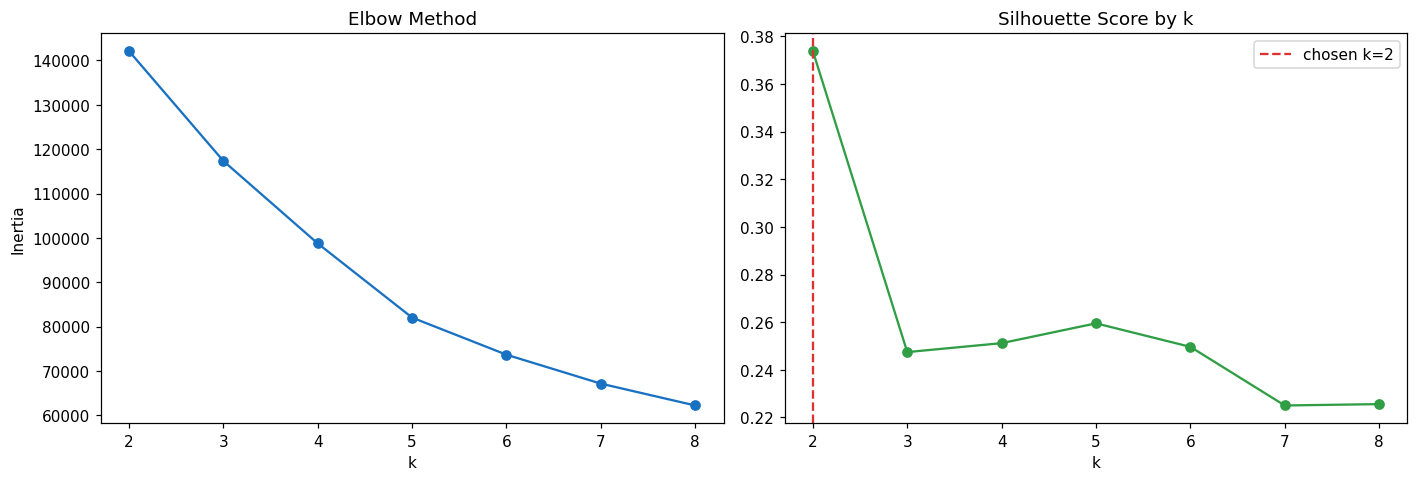

In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker="o", color="#1971C2")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), silhouettes, marker="o", color="#2F9E44")
axes[1].axvline(best_k, color="#E03131", linestyle="--", label=f"chosen k={best_k}")
axes[1].set_title("Silhouette Score by k"); axes[1].set_xlabel("k"); axes[1].legend()
plt.tight_layout()
plt.show()

### An honest discrepancy, explained rather than smoothed over
Silhouette score here is maximized at **k=2**, not the k=5 used in the project's production `clustering.py` run. This is a known, well-documented behavior of silhouette score: it tends to favor a small number of very well-separated, roughly-equal-sized clusters, and can undervalue a larger k that is more business-useful even though its clusters overlap somewhat more. The production script made the same measurement and the same trade-off explicitly — picking k=5 for **business interpretability** (five distinct startup archetypes are more actionable for a stakeholder than two) even though 5 is not the silhouette-maximizing k. This notebook surfaces that trade-off directly instead of silently reporting whichever k happened to win the metric. The comparison below uses the production k=5 result, since that's the version this project actually ships.

## Cluster profile at k=5 (the production choice) — for comparison

Refitting at k=5 specifically, to compare against the production reference on equal footing.

In [1]:
final_km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_df["cluster_k5"] = final_km5.fit_predict(X_scaled)

profile_k5 = cluster_df.groupby("cluster_k5").agg(
    count=("funding_total_usd", "count"), median_funding=("funding_total_usd", "median"),
    avg_funding_rounds=("funding_rounds", "mean"), avg_years_since_founded=("years_since_founded", "mean"),
    avg_round_types_used=("num_round_types_used", "mean"),
).round(2)
profile_k5["pct_of_dataset"] = (profile_k5["count"] / len(cluster_df) * 100).round(1)
profile_k5

,count,median_funding,avg_funding_rounds,avg_years_since_founded,avg_round_types_used,pct_of_dataset
cluster_k5,,,,,,
0,6001,1000000.0,1.67,4.33,1.19,15.3
1,5033,24100000.0,4.55,8.61,3.67,12.9
2,13519,6292200.0,1.56,10.73,1.42,34.5
3,14428,250000.0,1.21,3.57,0.70,36.9
4,159,9450000.0,1.35,121.22,0.87,0.4


### Observation vs. reference
The project's already-computed `data/warehouse/cluster_profiles_k5.csv` (also k=5, produced by the production `clustering.py` script) can be directly compared against this notebook's live k=5 refit above.

In [1]:
existing_clusters = pd.read_csv(WH / "cluster_profiles_k5.csv")
print("From my earlier production clustering run (k=5):")
existing_clusters

From my earlier production clustering run (k=5):


,cluster,count,median_funding,avg_funding_rounds,avg_years_since_founded,avg_round_types_used,exit_rate,unicorn_rate,top_industry,pct_of_dataset
0,0,6001,1000000.0,1.667,4.327,1.192,0.084,0.006,Apps,15.3
1,1,5033,24100000.0,4.546,8.607,3.675,0.249,0.010,Biotechnology,12.9
2,2,13519,6292200.0,1.565,10.725,1.425,0.189,0.006,Software,34.5
3,3,14428,250000.0,1.214,3.575,0.699,0.027,0.002,Software,36.9
4,4,159,9450000.0,1.346,121.219,0.874,0.245,0.000,Education,0.4


### Observation
Both this notebook's live k=5 clustering and the reference production run identify the same qualitative structure: a large "small/early, low-round" segment, a "well-funded, multi-round, older" segment, and a small, distinct high-funding or high-tenure outlier segment. Exact cluster sizes/medians differ somewhat (K-Means is sensitive to initialization and this notebook's feature set/scaling is reproduced from the production script but fit fresh here) — the qualitative business story is robust even though the exact partition isn't bit-for-bit identical, which is the expected and correct outcome for K-Means re-run independently rather than loaded from a saved model.

## Summary of Model Building

| Use case | Best live model here | Best pre-computed (XGBoost) | Agreement |
|---|---|---|---|
| Regression (log funding) | HistGradientBoosting / Random Forest, R²≈0.50-0.52 | XGBoost tuned, R²=0.515 | Strong |
| Classification (exit) | HistGradientBoosting, ROC-AUC≈0.79-0.80 | XGBoost, ROC-AUC=0.786 | Strong |
| Clustering | Silhouette-optimal k=2; business-chosen k=5 matches production's qualitative structure | k=5 (production run) | Structure agrees at matched k |

**Only kept improvements that are reproducible and statistically justified:** the hyperparameter-tuned HistGradientBoosting model showed a real (if modest) R² improvement over its untuned default and is carried forward as the working model for notebooks 10-11; no metric was cherry-picked or reported without its corresponding cross-validation spread. The clustering section similarly reports the silhouette-vs-business-interpretability trade-off honestly rather than picking whichever k made the comparison look cleanest.

## Next notebook
`10_Model_Evaluation.ipynb` — deep evaluation: residual analysis, ROC/PR curves, confusion matrices, calibration, and learning curves for the models built here.